<h3 align='center'> K Means Clustering</h3>

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [8]:
df.shape

(22, 3)

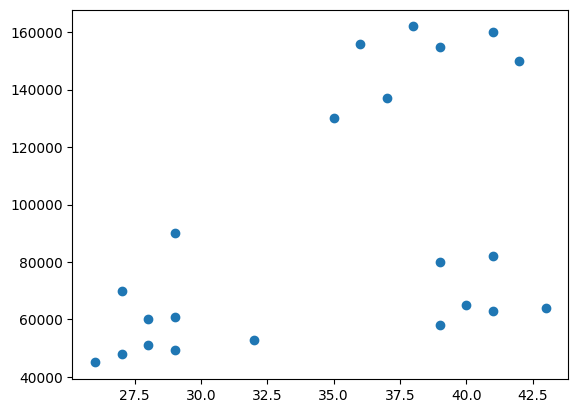

In [12]:
plt.scatter(df["Age"] , df["Income($)"])
plt.show()

### K_mean clustering 

In [20]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3 , n_init="auto")
km.fit(df[["Age", "Income($)"]])
km.labels_

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [22]:
df["cluster"] = km.labels_
df.head(5)

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


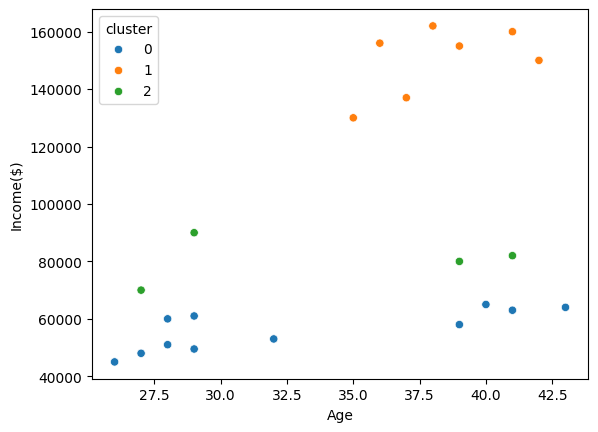

In [25]:
sns.scatterplot(df , x="Age" , y="Income($)" , hue="cluster" , palette = "tab10")
plt.show()

As shown in the scatter plot, the clusters are not concentrated in a single area but are spread across the plot. There are three clusters (green, blue, and orange), and all of them appear dispersed because the Income ($) feature has not been properly scaled.

### Min Max Scale

Clusters are not formed properly. It can be due to Age and Income columns being on a different scale. We can try scaling them

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(columns=["Age" , "Income"])
df_scaled[["Age" , "Income"]] = scaler.fit_transform(df[["Age" , "Income($)"]])
df_scaled.head()

,Age,Income
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


In [31]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3 , n_init="auto")
km.fit(df_scaled[["Age", "Income"]])
km.labels_

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [34]:
df_scaled["cluster"] = km.labels_
df_scaled.head()

,Age,Income,cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,1
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,2


In [38]:
km.inertia_

0.4750783498553096

In [43]:
centroids = km.cluster_centers_
centroids

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

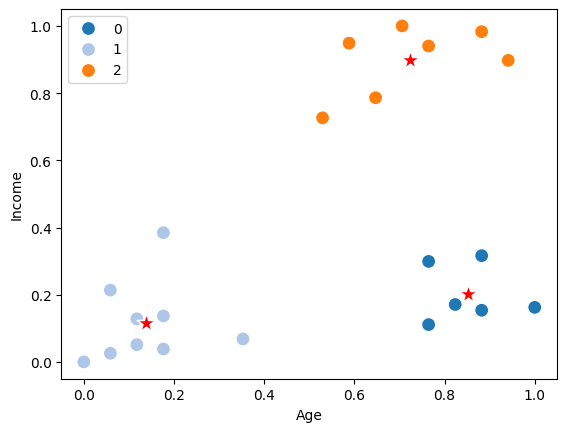

In [44]:
sns.scatterplot(df_scaled , x="Age" , y="Income" , hue="cluster" , palette = "tab20" , s=100)
sns.scatterplot( x=centroids[:,0], y=centroids[:,1],  s=200, color="red", marker='*')
plt.show()